In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Para usar a segunda GPU, por exemplo

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2025-01-14 16:50:09.750104: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [59]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Carregar o dataset diretamente do TensorFlow Datasets
dataset_name = "cats_vs_dogs"
(ds_train, ds_val), ds_info = tfds.load(
    dataset_name,
    split=["train[:80%]", "train[80%:]"],  # Divisão em treino e validação
    as_supervised=True,                   # Carregar imagens e rótulos
    with_info=True                        # Obter informações do dataset
)



In [60]:
categories = ['cats', 'dogs']

2025-01-15 10:02:29.249783: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-01-15 10:02:38.778390: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


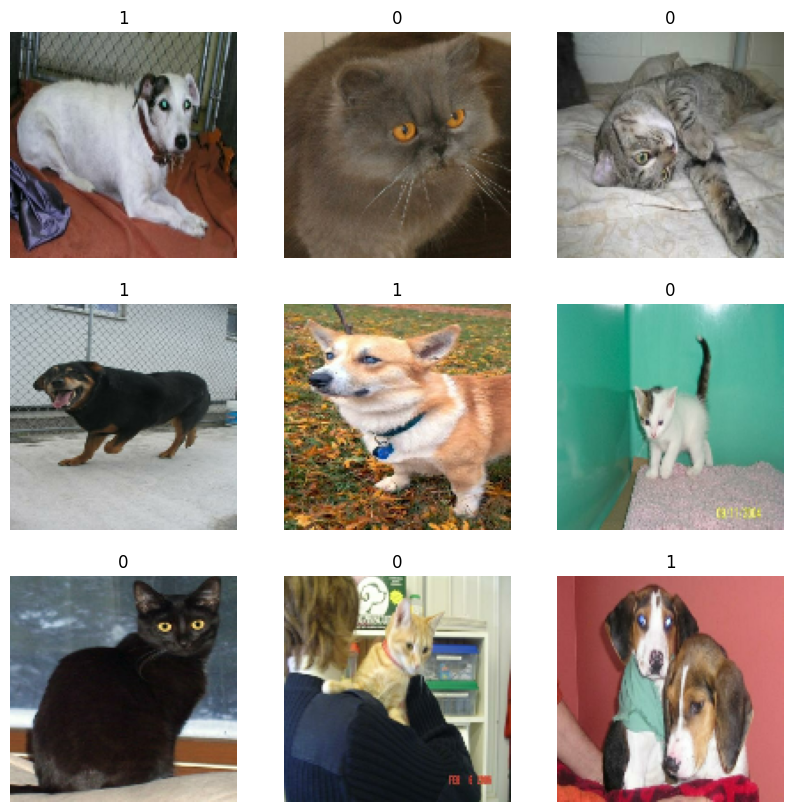

In [61]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Função para carregar e processar as imagens
def load_images(dataset, img_size=(128, 128)):
    images = []
    labels = []
    img_size_tensor = tf.convert_to_tensor(img_size, dtype=tf.int32)  # Converter img_size para Tensor
    for img, label in dataset:
        img = tf.image.resize(img, img_size_tensor).numpy() / 255.0  # Redimensionar e normalizar
        images.append(img)
        labels.append(label.numpy())
    return np.array(images), np.array(labels)

# Continue com o restante do seu código...

# Carregar imagens e rótulos
images_train, labels_train = load_images(ds_train)
images_val, labels_val = load_images(ds_val)

# Codificar os rótulos
le = LabelEncoder()
labels_encoded = le.fit_transform(labels_train)
labels_encoded = to_categorical(labels_encoded)

# Classes do dataset
class_names = le.classes_

# Exibir amostras de imagens
def display_sample_images(images, labels, class_names):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        idx = np.random.randint(len(images))
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[idx])
        plt.title(class_names[np.argmax(labels[idx])])
        plt.axis('off')
    plt.show()

# Exibir imagens de amostra
display_sample_images(images_train, labels_encoded, class_names)


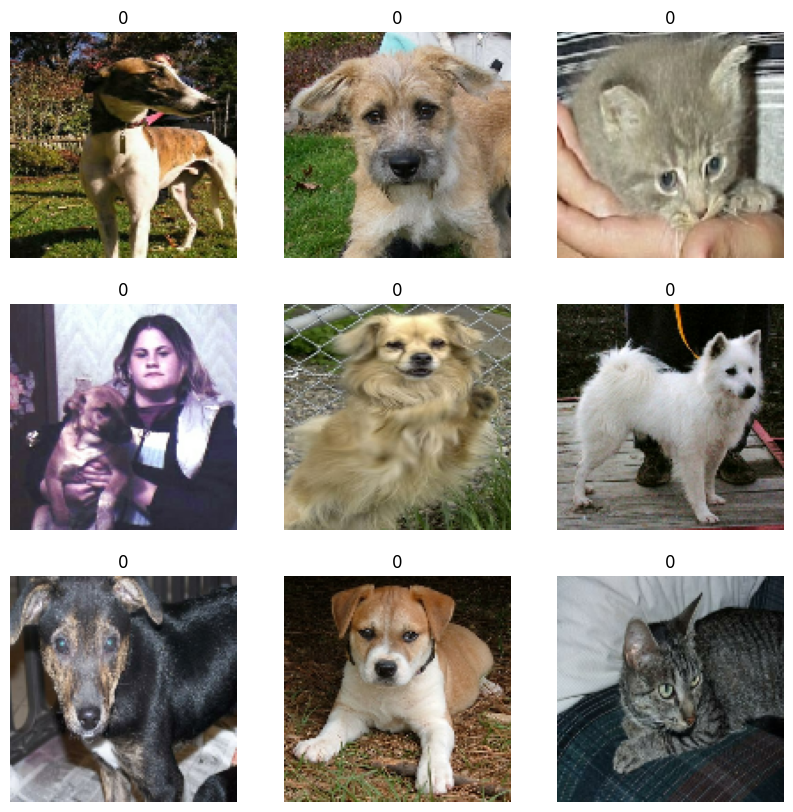

In [30]:
# Exibir imagens amostras
class_names = le.classes_
display_sample_images(images, labels_encoded.argmax(axis=1), class_names)

In [35]:
print(list(class_names))

[0, 1]


In [36]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(images, labels_encoded, test_size=0.2, random_state=42)

In [37]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X_train)

In [38]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load pre-trained ResNet50 model and add custom layers
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

model = Sequential()
model.add(resnet_base)
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(2, activation='softmax'))

In [39]:
# Freeze the ResNet50 base layers
resnet_base.trainable = False

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [40]:
# Model Training with callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    validation_data=(X_test, y_test),
                    epochs=20,
                    callbacks=[early_stopping, reduce_lr])

Epoch 1/20
466/466 [==============================] - 69s 124ms/step - loss: 0.7251 - accuracy: 0.5462 - val_loss: 0.6793 - val_accuracy: 0.5277 - lr: 0.0010
Epoch 2/20
466/466 [==============================] - 50s 107ms/step - loss: 0.6794 - accuracy: 0.5780 - val_loss: 0.6646 - val_accuracy: 0.5811 - lr: 0.0010
Epoch 3/20
466/466 [==============================] - 52s 111ms/step - loss: 0.6690 - accuracy: 0.5913 - val_loss: 0.6471 - val_accuracy: 0.6247 - lr: 0.0010
Epoch 4/20
466/466 [==============================] - 52s 111ms/step - loss: 0.6658 - accuracy: 0.5956 - val_loss: 0.6461 - val_accuracy: 0.6260 - lr: 0.0010
Epoch 5/20
466/466 [==============================] - 51s 109ms/step - loss: 0.6565 - accuracy: 0.6170 - val_loss: 0.6278 - val_accuracy: 0.6596 - lr: 0.0010
Epoch 6/20
466/466 [==============================] - 51s 109ms/step - loss: 0.6550 - accuracy: 0.6135 - val_loss: 0.6232 - val_accuracy: 0.6668 - lr: 0.0010
Epoch 7/20
466/466 [==============================] 

In [41]:
# Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

117/117 [==============================] - 7s 21ms/step


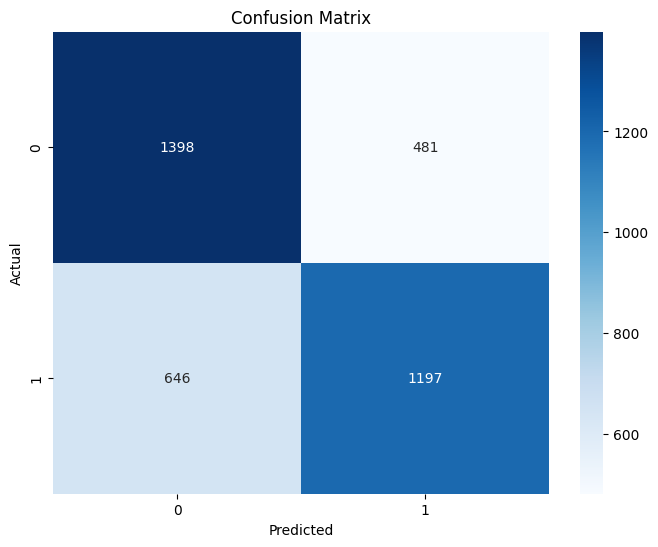

In [42]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [67]:
# Classification Report
class_names=['0','1']
class_report = classification_report(y_true, y_pred_classes, target_names=class_names)
print('Classification Report:')
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.74      0.71      1879
           1       0.71      0.65      0.68      1843

    accuracy                           0.70      3722
   macro avg       0.70      0.70      0.70      3722
weighted avg       0.70      0.70      0.70      3722



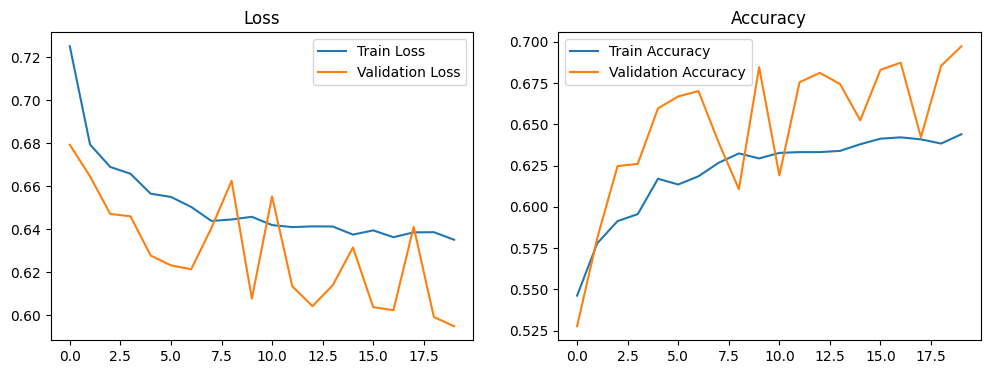

In [68]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

In [83]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Função para o Grad-CAM
def grad_cam(model, img_array, layer_name='conv5_block3_out'):
    # Criar um modelo para capturar a saída da camada convolucional e a saída final
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(layer_name).output, model.output])
    
    # Calcular as previsões e o gradiente em relação à predição correta
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        loss = preds[:, np.argmax(preds[0])]  # Perda com base na predição correta
    
    grads = tape.gradient(loss, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # Média dos gradientes
    
    # Acessar a saída da camada convolucional
    last_conv_layer_output = last_conv_layer_output[0]  # Remover a dimensão do batch
    
    # Calcular a ativação ponderada pelos gradientes
    weighted_activation = last_conv_layer_output * pooled_grads[tf.newaxis, tf.newaxis, :]
    
    # Gerar o heatmap
    heatmap = np.mean(weighted_activation, axis=-1)  # Média ao longo dos canais
    heatmap = np.maximum(heatmap, 0)  # Usar ReLU para eliminar valores negativos
    heatmap /= np.max(heatmap)  # Normalizar para o intervalo [0, 1]
    
    return heatmap

# Função para exibir a imagem com o Grad-CAM
def display_grad_cam(img_array, cam):
    # A imagem deve ser redimensionada para 128x128
    img_resized = cv2.resize(img_array, (128, 128))
    
    # Redimensionar o heatmap para o tamanho da imagem original (128x128)
    heatmap_resized = cv2.resize(cam, (128, 128))  # Ajustar para o tamanho da imagem original
    
    # Aplicar o heatmap à imagem
    heatmap = np.uint8(255 * heatmap_resized)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Superpor o heatmap na imagem
    superimposed_img = cv2.addWeighted(img_resized, 0.6, heatmap, 0.4, 0)
    
    # Exibir a imagem final
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

# Teste com uma imagem do conjunto de dados
img_index = 0
img_array = X_test[img_index]  # Imagem de teste

# Pré-processar a imagem para o modelo (128x128, já feito no seu código)
img_array = np.expand_dims(img_array, axis=0)  # Adicionar a dimensão do batch
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)  # Normalização

# Gerar o Grad-CAM
cam = grad_cam(model, img_array, layer_name='conv5_block3_out')

# Exibir a imagem com o Grad-CAM
display_grad_cam(X_test[img_index], cam)


ValueError: Input 0 of layer "model_6" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(1, 128, 128, 3)

In [72]:
resnet_layers = model.get_layer('resnet50').layers
for layer in resnet_layers:
    print(layer.name)


input_2
conv1_pad
conv1_conv
conv1_bn
conv1_relu
pool1_pad
pool1_pool
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_2_bn
conv2_block1_2_relu
conv2_block1_0_conv
conv2_block1_3_conv
conv2_block1_0_bn
conv2_block1_3_bn
conv2_block1_add
conv2_block1_out
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_2_bn
conv2_block2_2_relu
conv2_block2_3_conv
conv2_block2_3_bn
conv2_block2_add
conv2_block2_out
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_2_bn
conv2_block3_2_relu
conv2_block3_3_conv
conv2_block3_3_bn
conv2_block3_add
conv2_block3_out
conv3_block1_1_conv
conv3_block1_1_bn
conv3_block1_1_relu
conv3_block1_2_conv
conv3_block1_2_bn
conv3_block1_2_relu
conv3_block1_0_conv
conv3_block1_3_conv
conv3_block1_0_bn
conv3_block1_3_bn
conv3_block1_add
conv3_block1_out
conv3_block2_1_conv
conv3_block2_1_bn
conv3_block2_1_relu
conv3_block2_2_conv
conv3_block2_2_bn
conv3_